In [132]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [133]:
from testgen.prompts import Sensors

labels = Sensors.split("\n")
for i, sensor in enumerate(labels):
    labels[i] = sensor[sensor.find("(")+1: sensor.find(")")].strip()
    
labels = np.array(labels)

labels

array(['Acc', 'WSA', 'WS', 'YR', 'ST'], dtype='<U3')

In [134]:
# read results file
base_path = Path().cwd()
results_path = base_path.parent / "results"

available_results = list(results_path.glob("single*.json"))

for f in available_results: print(f.name)

single_gpt-4o-mini_n-1_acc-0.926_10.24.2024-14:15:47.json


In [135]:
filename = "single_gpt-4o-mini_n-1_acc-0.926_10.24.2024-14:15:47"
filename += ".json"

file_under_investigation = results_path / filename
with file_under_investigation.open("r") as f:
    data = json.load(f)

In [136]:
# split responses and general stats
responses = pd.DataFrame(data["responses"])
responses.set_index("idx", inplace=True)
del data["responses"]

# collect stats per experiment
stats = pd.DataFrame({k: [v]for k,v in data.items()})

# collect label names for predictions and ground truth
responses["true_label"] = responses["true_vector"].map(lambda x: " & ".join(labels[np.array(x[1:-1].split(",")).astype(bool)]) )
responses["pred_label"] = responses["pred_vector"].map(lambda x: " & ".join(labels[np.array(x[1:-1].split(",")).astype(bool)]) )

# accuracy per sensor
summarize_ = responses.groupby(["true_label"]).aggregate({
    "accuracy": "sum",
    "true_label": "count"
})

summarize_.columns = ["true", "total"]
summarize_["false"] = summarize_["total"] - summarize_["true"]
summarize_["accuracy"] = np.round(summarize_["true"] / summarize_["total"], 2)


summarize_

,true,total,false,accuracy
true_label,,,,
Acc,29,31,2,0.94
Acc & WSA,25,25,0,1.00
ST,39,46,7,0.85
WS,26,26,0,1.00
WSA,28,33,5,0.85
YR,28,28,0,1.00


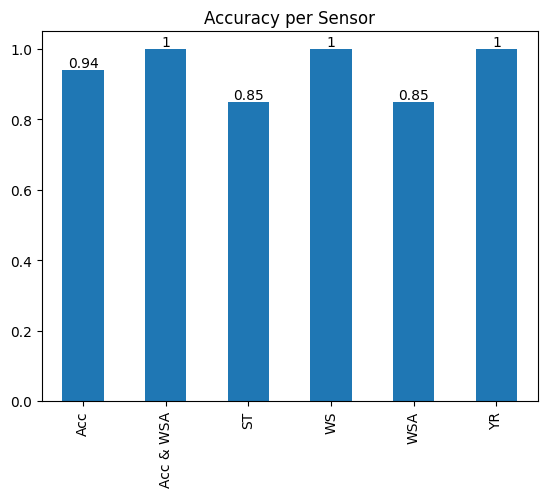

In [137]:
def plot_summarize(summarize_):
    ax = summarize_["accuracy"].plot.bar(
        title="Accuracy per Sensor",
        xlabel="",
    )

    _ = ax.bar_label(ax.containers[0])
    
plot_summarize(summarize_)

In [140]:
def calc_scores(df):
    df_scores = pd.DataFrame(columns=["sensor", "accuracy", "precision", "recall", "f1"])

    y_true = df["true_label"]
    y_pred = df["pred_label"]
    unique_labels = np.unique(y_true)
    unique_labels.sort()

    accuracy_score_ = round(accuracy_score(y_true, y_pred), 2)
    precision_score_ = round(
        precision_score(y_true, y_pred, average="weighted", labels=unique_labels), 2
    )
    recall_score_ = round(
        recall_score(y_true, y_pred, average="weighted", labels=unique_labels), 2
    )
    f1_score_ = round(f1_score(y_true, y_pred, average="weighted", labels=unique_labels), 2)

    df_scores.loc[df_scores.shape[0] + 1] = [
        "All",
        accuracy_score_,
        precision_score_,
        recall_score_,
        f1_score_,
    ]


    for label in unique_labels:
        t_ = df[df["true_label"] == label]

        y_true_ = t_["true_label"]
        y_pred_ = t_["pred_label"]

        accuracy_score_ = round(accuracy_score(y_true_, y_pred_), 2)
        precision_score_ = round(
            precision_score(y_true_, y_pred_, average="weighted", labels=[label]), 2
        )
        recall_score_ = round(
            recall_score(y_true_, y_pred_, average="weighted", labels=[label]), 2
        )
        f1_score_ = round(f1_score(y_true_, y_pred_, average="weighted", labels=[label]), 2)

        df_scores.loc[df_scores.shape[0] + 1] = [
            label,
            accuracy_score_,
            precision_score_,
            recall_score_,
            f1_score_,
        ]
        
    return df_scores.set_index("sensor")

In [145]:
df_scores = calc_scores(responses)
df_scores

,accuracy,precision,recall,f1
sensor,,,,
All,0.93,0.95,0.93,0.94
Acc,0.94,1.00,0.94,0.97
Acc & WSA,1.00,1.00,1.00,1.00
ST,0.85,1.00,0.85,0.92
WS,1.00,1.00,1.00,1.00
WSA,0.85,1.00,0.85,0.92
YR,1.00,1.00,1.00,1.00


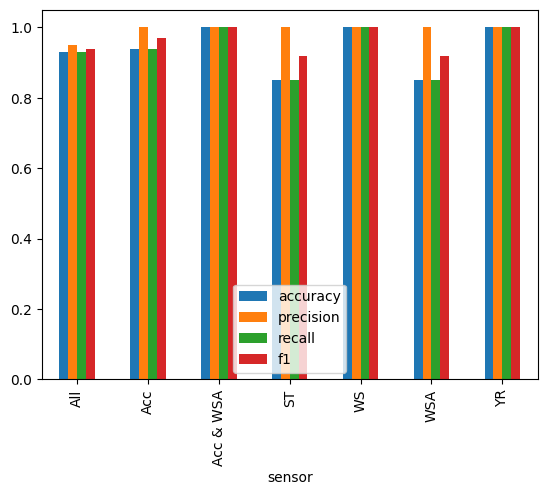

In [146]:
ax = df_scores.plot.bar()

# for c in ax.containers:
#     _ = ax.bar_label(c)